## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.
: 같은 군집 안에 속한 데이터 포인트들의 서로 유사한 정도.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.
서로 다른 군집들이 멀리 떨어져 있는 정도.



문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2817301379.py:20: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.

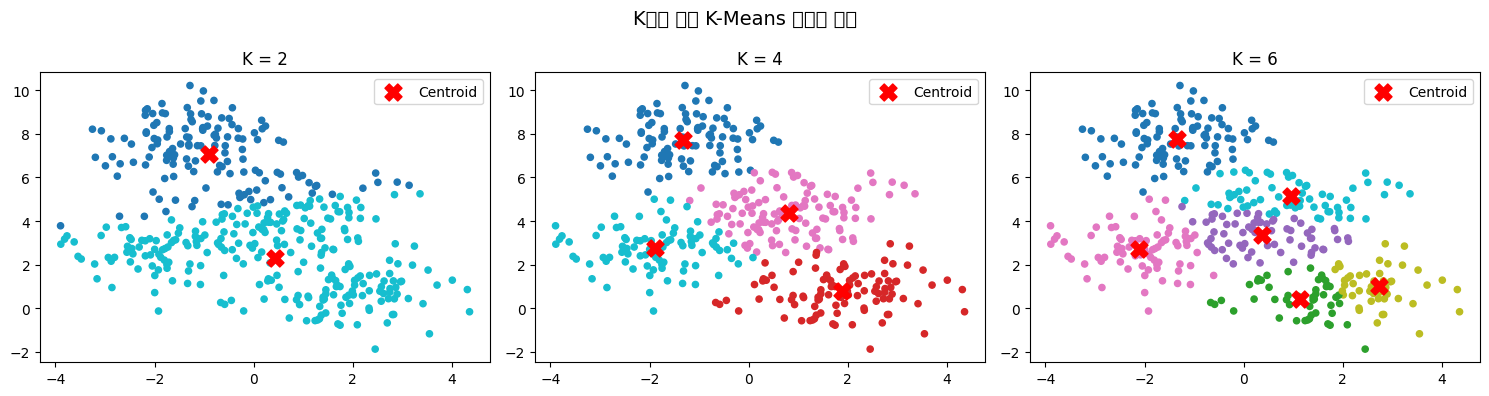

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=400, centers=4, n_features=2, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_values = [2, 4, 6]

for ax, k in zip(axes, k_values):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=20)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', marker='X', s=150, label='Centroid')
    ax.set_title(f'K = {k}')
    ax.legend()

plt.suptitle('K값에 따른 K-Means 군집화 비교', fontsize=14)
plt.tight_layout()
plt.show()

문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

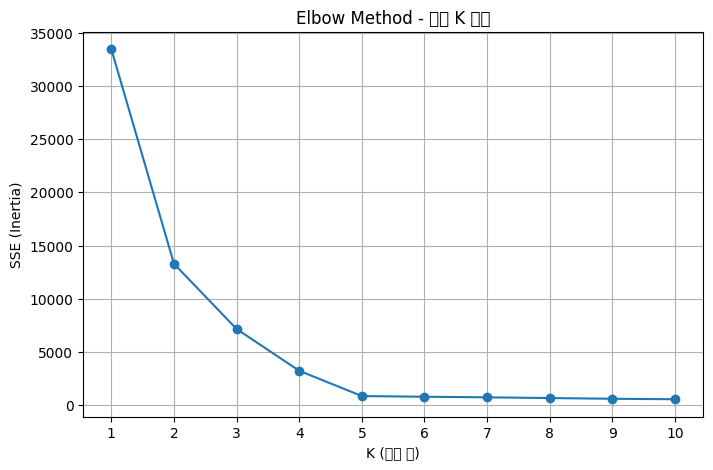

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

#K-means 수행 과정을 작성해주세요
sse = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=10)
    km.fit(X)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('K (군집 수)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method - 최적 K 탐색')
plt.xticks(k_range)
plt.grid(True)
plt.show()

문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

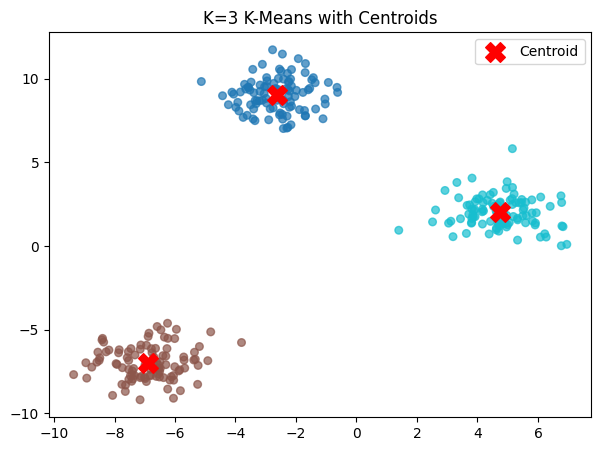

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

km = KMeans(n_clusters=3, random_state=42)
labels = km.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.title('K=3 K-Means with Centroids')
plt.legend()
plt.show()

문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

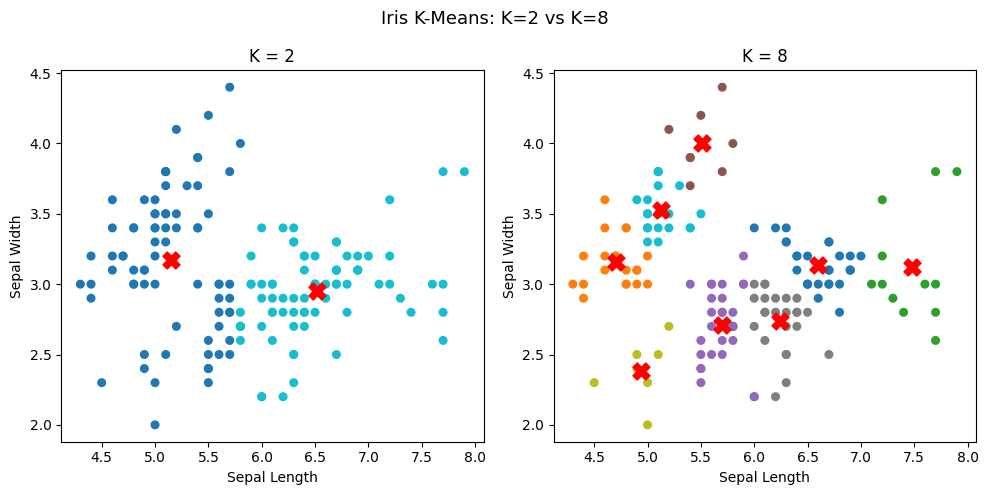

In [5]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))

for ax, k in zip(axes, [2, 8]):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', marker='X', s=150)
    ax.set_title(f'K = {k}')
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Sepal Width')

plt.suptitle('Iris K-Means: K=2 vs K=8', fontsize=13)
plt.tight_layout()
plt.show()

k 작을 때: 다른 클래스가 하나로 합쳐짐.
k 클 때: 하나의 클래스가 여러 개로 쪼개짐.

문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.
: 데이터 포인트 하나가 자신의 군집에 얼마나 잘 속해 있는지 나타내는 지표.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.
- 1: 군집이 잘 분리됨
- 0: 군집 경계에 위치. 애매함.
- 음수: 잘못된 군집에 배정 가능성 높.

문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

클러스터 중심 (cluster_centers_):
[[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


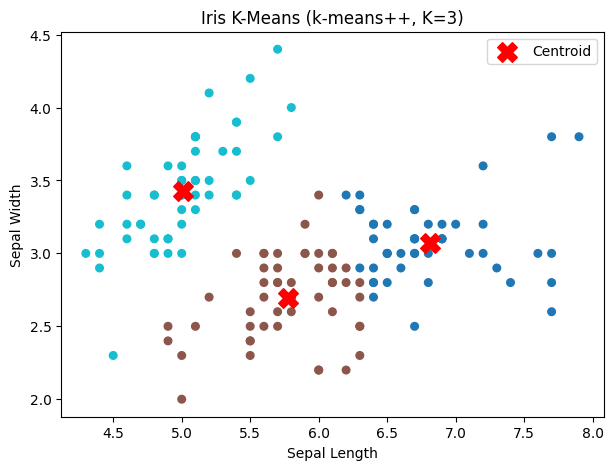

In [6]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data[:, :2]

km = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
labels = km.fit_predict(X)

print("클러스터 중심 (cluster_centers_):")
print(km.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.title('Iris K-Means (k-means++, K=3)')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()

문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters: 군집의 수 K 지정.

init: 초기 중심점 설정 방식.

n_init: 서로 다른 초기값으로 K-Means를 반복 실행하는 횟수.

max_iter: 한 번의 실행에서 허용되는 최대 반복 횟수

random_state: 난수 시드

### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

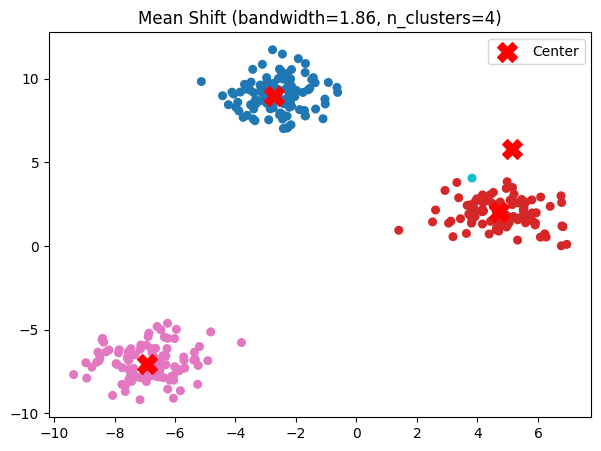

In [7]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

bandwidth = estimate_bandwidth(X, quantile=0.2)
ms = MeanShift(bandwidth=bandwidth)
labels = ms.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30)
plt.scatter(ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Center')
plt.title(f'Mean Shift (bandwidth={bandwidth:.2f}, n_clusters={len(ms.cluster_centers_)})')
plt.legend()
plt.show()

#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/2509730921.py:21: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.

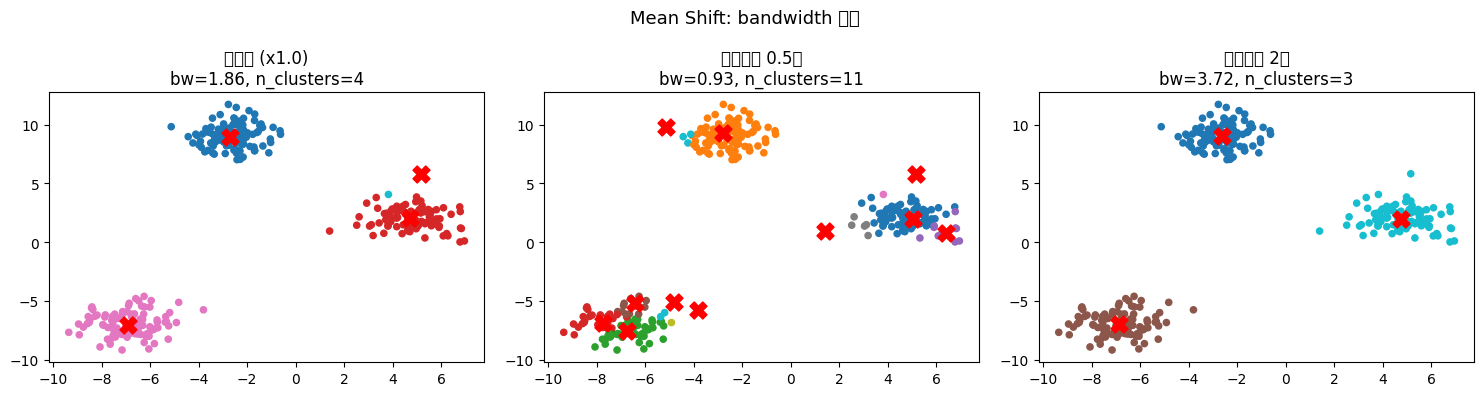

In [8]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

bw = estimate_bandwidth(X, quantile=0.2)
cases = [('추정값 (x1.0)', bw), ('추정값의 0.5배', bw * 0.5), ('추정값의 2배', bw * 2.0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, b) in zip(axes, cases):
    ms = MeanShift(bandwidth=b)
    labels = ms.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=20)
    ax.scatter(ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1],
               c='red', marker='X', s=150)
    ax.set_title(f'{title}\nbw={b:.2f}, n_clusters={len(ms.cluster_centers_)}')

plt.suptitle('Mean Shift: bandwidth 비교', fontsize=13)
plt.tight_layout()
plt.show()

#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

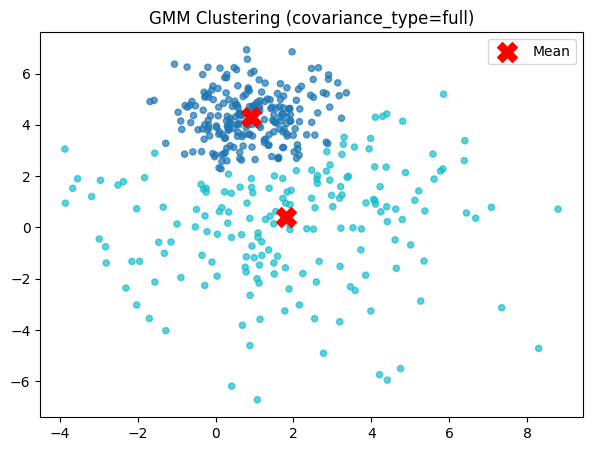

In [9]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=400, centers=2, n_features=2,
                  cluster_std=[1.0, 2.5], random_state=0)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=20, alpha=0.7)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
            c='red', marker='X', s=200, label='Mean')
plt.title('GMM Clustering (covariance_type=full)')
plt.legend()
plt.show()

#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

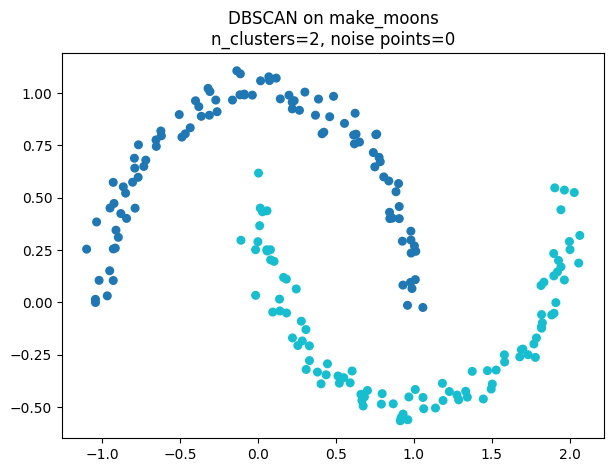

In [10]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30)
plt.title(f'DBSCAN on make_moons\nn_clusters={n_clusters}, noise points={n_noise}')
plt.show()

### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

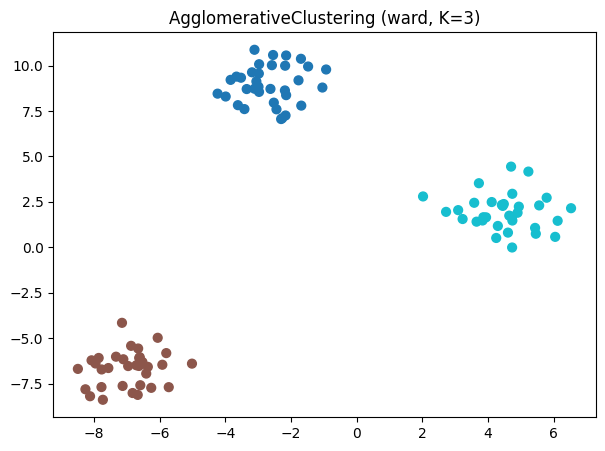

In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=40)
plt.title('AgglomerativeClustering (ward, K=3)')
plt.show()

#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

/tmp/ipykernel_10023/152677163.py:17: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10023/152677163.py:17: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


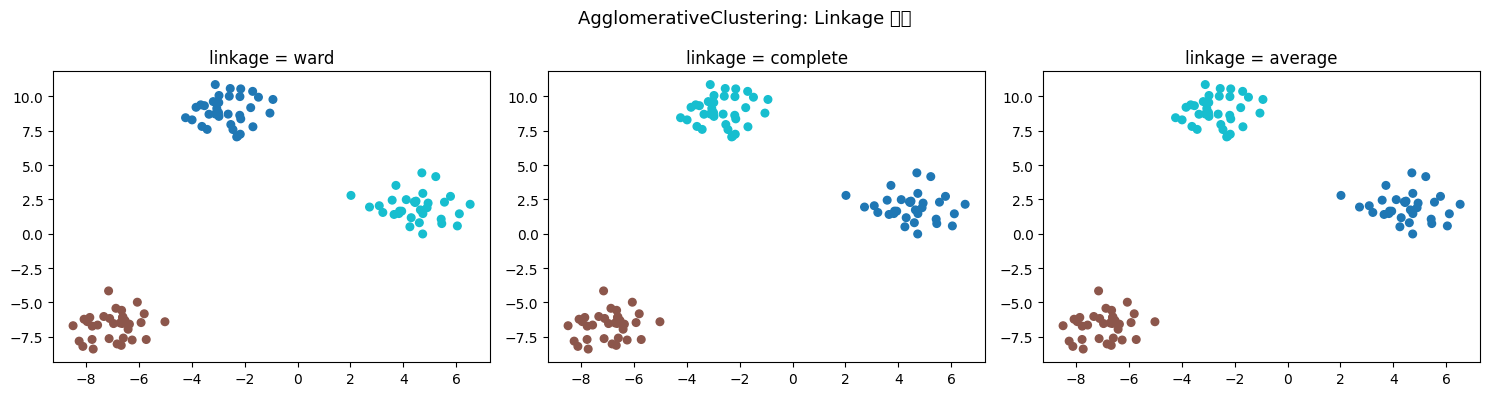

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
linkages = ['ward', 'complete', 'average']

for ax, link in zip(axes, linkages):
    agg = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30)
    ax.set_title(f'linkage = {link}')

plt.suptitle('AgglomerativeClustering: Linkage 비교', fontsize=13)
plt.tight_layout()
plt.show()

#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

In [ ]:
- Recency: 가장 최근 구매일로부터 현재까지의 경과 일수
- Frequency: 일정 기간 동안의 총 구매 횟수
- Monetary: 일정 기간 동안의 총 구매 금액

구매 이력 데이터만으로 계산할 수 있어 객관적임.

#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [13]:
import pandas as pd

data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01',
                     '2023-01-20', '2023-02-10',
                     '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20',
                     '2023-01-25', '2023-02-05',
                     '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}

df = pd.DataFrame(data)

# 1. PurchaseDate를 datetime 타입으로 변환
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 2. 기준일 설정
reference_date = pd.Timestamp('2023-03-01')

# 3. RFM 계산
rfm = df.groupby('CustomerID').agg(
    Recency=('PurchaseDate', lambda x: (reference_date - x.max()).days),
    Frequency=('PurchaseDate', 'count'),
    Monetary=('Price', 'sum')
).reset_index()

print(rfm.head())
rfm

   CustomerID  Recency  Frequency  Monetary
0           1       28          3       450
1           2       19          2       170
2           3        9          4       630
3           4       24          2       320
4           5       52          2       600


,CustomerID,Recency,Frequency,Monetary
0,1,28,3,450
1,2,19,2,170
2,3,9,4,630
3,4,24,2,320
4,5,52,2,600
